In [1]:
import numpy as np, matplotlib.pyplot as plt

Solution to Question 1



The envelope constant M is: 5.999999729945999


The acceptance rate is: 0.41542


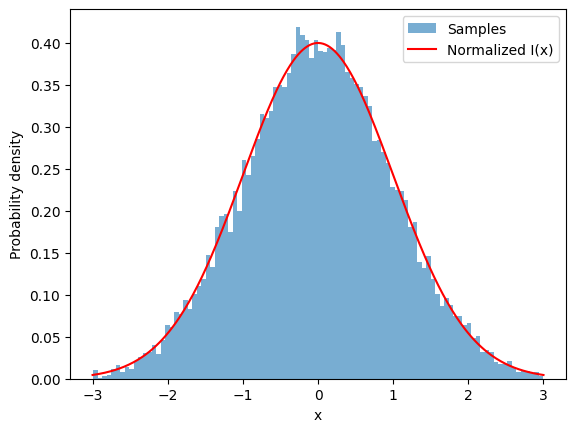

In [ ]:
# Part a
def I(x, sigma):
    return np.exp(-x**2/(2*sigma**2))


L = 3.0
sigma = 1.0
N = 50000

x = np.linspace(-L, L, 10000)  # detector range
g = 1/(2*L) # Uniform proposal distribution
M = np.max(I(x, sigma)/g)
print('\n'+'='*60+'\n')
print(f"The envelope constant M is: {M}")


x_proposal = np.random.uniform(-L, L, N) # generated 50,000 samples distributed accroding to I(x)
u = np.random.rand(N)

accepted = x_proposal[u < I(x_proposal, sigma)/(M*g)]
acceptance_rate = len(accepted)/N

print('\n'+'='*60+'\n')
print(f"The acceptance rate is: {acceptance_rate}")


'''Plotting a noralized histogram'''
xs = np.linspace(-L, L, 400)
plt.hist(accepted, bins=100, density=True, alpha=0.6, label="Samples")
plt.plot(xs, I(xs,sigma)/np.trapezoid(I(xs, sigma), xs), 'r', label="Normalized I(x)") # normalizing by calculating the integral, numerically
plt.legend()
plt.xlabel("x")
plt.ylabel("Probability density")
plt.show()


In [4]:
# Part b
"""
Graphically, accept-reject sampling places random points uniformly inside a rectangle of width 2L and height M g(x) that completely encloses curve I(x). A proposed point (x,y) is accepted if it lies below the curve I(x)
Becuse the points are uniformly distributed over the rectangle, thr fraction of accepted points equals the ratio of the area under I(x) to the area of the rectangle. Therefore, the acceptance rate directly represents the fraction of the rectangular area that lies beneath the curve I(x), which is why it is propotional to the integral I(x).
"""
S_est = M*acceptance_rate
print('\n'+'='*60+'\n')
print(f"Total Signal Strength is: {S_est}")


# Part c
"""
The choice of proposal distribution affects sampling efficiency because a proposal that closely matches the shape of the target distribution leads to a higher acceptance rate and fewer rejected samples. A poorly matched proposal wastes computational effort by proposing points in low-probability regions. Accept–reject sampling avoids explicit normalization because it only requires the target function up to a constant factor, using relative heights to decide acceptance rather than a normalized probability density.
"""
x2_mean = np.mean(accepted**2)
print('\n'+'='*60+'\n')
print(f"Mean Squared Position is: {x2_mean}")



Total Signal Strength is: 2.492519887814167


Mean Squared Position is: 0.9718528899678741


Solution to Question 2



The Stationary pobabilitie are:
A = 0.5600000000000003, B = 0.31999999999999984, C = 0.11999999999999988


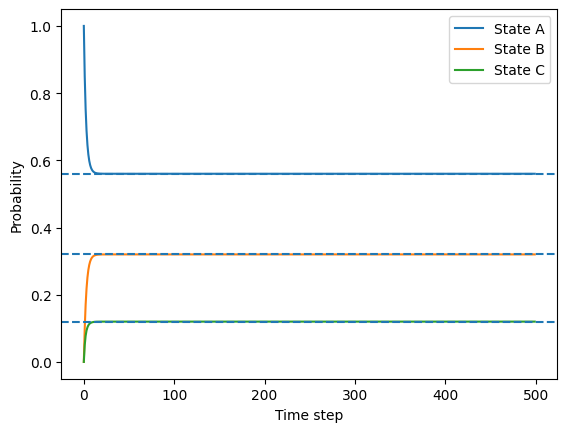

'\nThe system reaches equilibrium relatively quickly, within a few tens of timesteps, as the probabilities converge smoothly to their stationary values. State A equilibrates first because it has the largest self-transition probability (0.85) and strong incoming transitions from the other states, causing it to stabilize rapidly. The structure of the transition matrix, with sizable off-diagonal elements, ensures efficient mixing and fast relaxation.\n'

In [7]:
# Part a

P = np.array([[0.85, 0.10, 0.05],
              [0.15, 0.75, 0.10],
              [0.30, 0.20, 0.50]])

vals, vecs = np.linalg.eig(P.T) # stationary distribution

idx = np.argmin(np.abs(vals - 1))
pi_stat = np.real(vecs[:, idx])
pi_stat /= np.sum(pi_stat)
print('\n'+'='*60+'\n')
print("The Stationary pobabilitie are:")
print(f"A = {pi_stat[0]}, B = {pi_stat[1]}, C = {pi_stat[2]}")

"""
The lowest-energy state does not have probability 1 because thermal fluctuations allow the system to transition to higher-energy states with nonzero probability. The stationary distribution is determined not only by energy differences but also by the transition probabilities, which encode how easily the system moves between states. As a result, even excited states retain finite occupancy if transitions into them occur frequently enough.
"""


# Part b
# Time evolution
pi = np.array([1.0, 0.0, 0.0])
history = []

for _ in range(500):
    history.append(pi)
    pi = pi @ P

history = np.array(history)

plt.plot(history[:,0], label="State A")
plt.plot(history[:,1], label="State B")
plt.plot(history[:,2], label="State C")

plt.axhline(pi_stat[0], linestyle='--')
plt.axhline(pi_stat[1], linestyle='--')
plt.axhline(pi_stat[2], linestyle='--')

plt.xlabel("Time step")
plt.ylabel("Probability")
plt.legend()
plt.show()

"""
The system reaches equilibrium relatively quickly, within a few tens of timesteps, as the probabilities converge smoothly to their stationary values. State A equilibrates first because it has the largest self-transition probability (0.85) and strong incoming transitions from the other states, causing it to stabilize rapidly. The structure of the transition matrix, with sizable off-diagonal elements, ensures efficient mixing and fast relaxation.
"""

Solution to Question 3

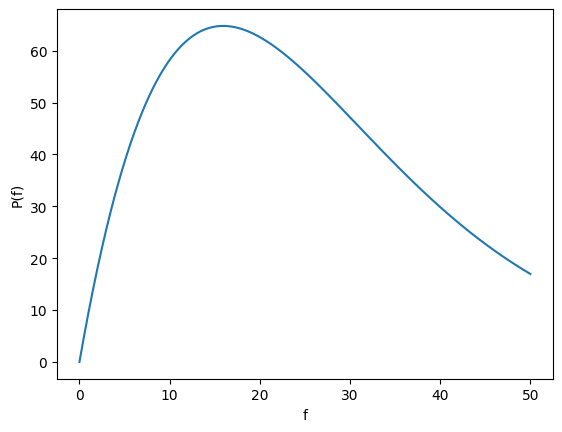

In [ ]:
# Part a
T = 10.0

def P_f(f):
    return f**2/(np.exp(f/T) - 1)

fs = np.linspace(0.001, 50, 1000)
plt.plot(fs, P_f(fs))
plt.xlabel("f")
plt.ylabel("P(f)")
plt.show()

"""
At small frequencies, P(f) grows approximately linearly with f because e^(f/T)-1 approximately equal to f/T, so P(f) approximately equal to Tf. At large frequencies, the exponential term dominates the denominator, causing P(f) to decay rapidly like f^2 e^(-f/T). The function has a single peak at an intermediate frequency, which from a plot is around f=20-25 GHz.
A good choice for the proposal distribution q(f) is a truncated exponential distribution on [0,50] with a scale comparable to T. This proposal peaks near low-to-intermediate frequencies and has an exponential decay similar to the tail of P(f), making it a reasonable envelope approximation. By concentrating samples in the region where P(f) is largest and avoiding excessive sampling where the integrand is negligible, importance sampling significantly reduces variance compared to uniform sampling over [0,50].
"""

In [10]:
# Part b

# Naive Monte Carlo
N = 50000
f_naive = np.random.uniform(0, 50, N)
samples_naive = P_f(f_naive)*50
phi_naive = np.mean(samples_naive)
var_naive = np.var(samples_naive)

print(f"Phi_naive = {phi_naive}, var_naive = {var_naive}")

# Importance sampling using exponential proposal
lam = 1/10
f_is = np.random.exponential(1/lam, N)
f_is = f_is[f_is < 50]

q = lam*np.exp(-lam*f_is)
samples_is = P_f(f_is)/q
phi_is = np.mean(samples_is)
var_is = np.var(samples_is)

print(f"phi_is = {phi_is}, var_is = {var_is}")


# Part c

"""
The naive uniform sampling method wastes samples because it draws frequencies evenly over [0,50], even though P(f) is extremely small at large frequencies where the exponential term dominates, contributing almost nothing to the integral. As a result, many samples add negligible weight but still increase variance. By matching the proposal distribution to the envelope of P(f), more samples are concentrated near the peak and in regions where the integrand is significant. The chosen exponential proposal reflects the rapid high-frequency decay of P(f), ensuring efficient sampling and reduced variance compared to uniform sampling.
"""

Phi_naive = 2158.0019247198393, var_naive = 695042.249468791
phi_is = 2162.7365112099164, var_is = 10688510.78271894


'\nThe naive uniform sampling method wastes samples because it draws frequencies evenly over [0,50], even though P(f) is extremely small at large frequencies where the exponential term dominates, contributing almost nothing to the integral. As a result, many samples add negligible weight but still increase variance. By matching the proposal distribution to the envelope of P(f), more samples are concentrated near the peak and in regions where the integrand is significant. The chosen exponential proposal reflects the rapid high-frequency decay of P(f), ensuring efficient sampling and reduced variance compared to uniform sampling.\n'